# 20 — Inversion engine benchmark

Compares four inversion engines on `S2L2A_example.nc` (267×449, 8 bands)
using `albert_mobley` / `albert_mobley_jax`, 1 free param (zB), identical noise.

| Engine | Loop | Prior | Parallelism | Early exit |
|---|---|---|---|---|
| `lmfit_engine` | Python for-loop | no | sequential px-by-px | per pixel |
| `oe_engine` | static unroll (`n_iter`) | yes | JAX vmap | never |
| `oe_engine_optx` | `lax.while_loop` | yes | JAX vmap | per batch |
| `lsq_engine_optx` | `lax.while_loop` | no | JAX vmap | per batch |

A second sweep varies `tile_size` for `oe_engine_optx` to find the crossover
between per-tile dispatch cost and the one-hard-pixel-holds-the-batch overhead.

In [1]:
import os
import time
import numpy as np
import xarray as xr
import lmfit
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from bio_optics.water.reflectance import albert_mobley_jax
from bio_optics.inversion import oe_engine, oe_engine_optx, lsq_engine_optx, lmfit_engine
from bio_optics.image_processing import dask_engine

jax.config.update('jax_enable_x64', True)
print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


In [2]:
NOISE      = 0.005   # Rrs noise [1/sr]
MAX_STEPS  = 100     # optimistix iteration cap
N_ITER     = 20      # oe_engine static unroll depth
MAX_NFEV   = 400     # lmfit max function evaluations (1 free param → 2 fwd calls/step)
TILE_SIZE  = 1024    # pixels/tile — matches NB04 chunk size (32×32)

DATA_PATH = os.path.join(os.getcwd(), 'example_data', 'S2L2A_example.nc')

# Sentinel-2A band centres for B02-B8A (8 bands)
S2_WAVELENGTHS = np.array([492.4, 559.8, 664.6, 704.1, 740.5, 782.8, 832.8, 864.7])

## 1  Load data

In [3]:
dataset   = xr.open_dataset(DATA_PATH)
print('Data variables:', list(dataset.data_vars))

band_vars   = list(dataset.data_vars)[1:]   # skip spatial_ref / crs
wavelengths = S2_WAVELENGTHS[:len(band_vars)]

# High-tide (time=1) surface reflectance -> Rrs [1/sr]
Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_water = int(np.isfinite(Rrs_image).all(axis=-1).sum())

print(f'Image   : {n_rows}x{n_cols} = {n_rows*n_cols} pixels, {n_obs} bands')
print(f'n_water : {n_water}  ({100*n_water/(n_rows*n_cols):.1f}% non-NaN)')
print(f'lambda  : {wavelengths[0]:.1f}-{wavelengths[-1]:.1f} nm')

Data variables: ['crs', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A']
Image   : 267x449 = 119883 pixels, 8 bands
n_water : 119883  (100.0% non-NaN)
lambda  : 492.4-864.7 nm


## 2  Parameters & forward model

Single free param: depth (zB). All water-column IOPs fixed at zero (clear water +
bottom only), matching the NB04 production setup. sigma_a=0.7 for zB (log-space
prior, ~factor-8 range at ±3σ). Bottom fractions fixed at f_0=1.

In [4]:
params = lmfit.Parameters()

# water-column params — all fixed at zero (clear water + bottom only)
params.add('C_0',   value=0.0, vary=False)
params.add('C_Y',   value=0.0, vary=False)
params.add('C_Mie', value=0.0, vary=False)

for name in ['C_1','C_2','C_3','C_4','C_5','C_X']:
    params.add(name, value=0.0, vary=False)
params.add('S',                   value=0.014, vary=False)
params.add('S_NAP',               value=0.011, vary=False)
params.add('K',                   value=0.0,   vary=False)
params.add('lambda_0',            value=440.0, vary=False)
params.add('lambda_S',            value=500.0, vary=False)
params.add('T_W',                 value=18.0,  vary=False)
params.add('T_W_0',               value=20.0,  vary=False)
params.add('a_NAP_spec_lambda_0', value=0.041, vary=False)
params.add('bb_phy_spec',         value=0.0010, vary=False)
params.add('bb_Mie_spec',         value=0.0042, vary=False)
params.add('bb_X_spec',           value=0.0086, vary=False)
params.add('b_X_norm_factor',     value=1.0,    vary=False)
params.add('n',                   value=-1.0,   vary=False)
params.add('fresh',               value=False,  vary=False)

# geometry
params.add('theta_sun',  value=np.radians(30), vary=False)
params.add('theta_view', value=np.radians(0),  vary=False)
params.add('n1',         value=1.0,    vary=False)
params.add('n2',         value=1.33,   vary=False)
params.add('kappa_0',    value=1.0546, vary=False)

# bathymetry — only free parameter
params.add('zB', value=0.5, min=0.01, max=50.0, vary=True)
for i in range(6):
    params.add(f'f_{i}', value=(1.0 if i == 0 else 0.0), vary=False)
    params.add(f'B_{i}', value=1/np.pi, vary=False)

log_params = ['zB']
sigma_a    = {'zB': 0.7}

free = [n for n, p in params.items() if p.vary]
print(f'Free params ({len(free)}): {free}')

Free params (1): ['zB']


In [5]:
pre = albert_mobley_jax.precompute(wavelengths)

param_names = list(params.keys())
f_vec = albert_mobley_jax.make_forward_vec(param_names, pre)

# InversionSetup shared by all JAX engines
setup = oe_engine.build_inversion(params, f_vec, sigma_a, log_params=log_params)

x_prior   = jnp.array([float(params[n].value) for n in param_names])
Rrs_prior = np.array(f_vec(x_prior))
print(f'fit_names : {setup.fit_names}')
print(f'Rrs_prior : [{Rrs_prior.min():.4f}, {Rrs_prior.max():.4f}] 1/sr')

fit_names : ['zB']
Rrs_prior : [0.0011, 0.3435] 1/sr


In [6]:
import functools
from bio_optics.water.reflectance import albert_mobley
from bio_optics.helper import resampling

# All precomputable arrays from albert_mobley.forward — fixed-param spectral shapes
# computed once here, baked in via functools.partial so every TRF eval pays zero cost.
# bb_w and n2 are taken from the JAX forward (morel bb_w via pre['bb_w']; scalar
# n2=1.33) so lmfit fits the *identical* forward model as the JAX engines — a fair
# comparison. (Default numpy uses resample_bb_w + spectral resample_n, which differ.)
_S         = float(params['S'].value)
_S_NAP     = float(params['S_NAP'].value)
_lambda_0  = float(params['lambda_0'].value)
_lambda_S  = float(params['lambda_S'].value)
_n         = float(params['n'].value)
_b_X_nf    = float(params['b_X_norm_factor'].value)

_pre_np = dict(
    a_w_res         = resampling.resample_a_w(wavelengths),
    da_w_div_dT_res = resampling.resample_da_w_div_dT(wavelengths),
    a_i_spec_res    = resampling.resample_a_i_spec(wavelengths),
    b_phy_norm_res  = resampling.resample_b_phy_norm(wavelengths),
    bb_w_res        = np.array(pre['bb_w']),   # match JAX forward (morel), not resample_bb_w
    R_b_i_res       = resampling.resample_R_b_i(wavelengths),
    n2_res          = None,                     # match JAX forward (scalar n2=1.33), not spectral
    a_Y_N_res       = np.exp(-_S     * (wavelengths - _lambda_0)),
    a_NAP_N_res     = np.exp(-_S_NAP * (wavelengths - _lambda_0)),
    b_X_norm_res    = np.ones(len(wavelengths)) * _b_X_nf,
    b_Mie_norm_res  = (wavelengths / _lambda_S) ** _n,
)

forward_func_np = functools.partial(albert_mobley.forward, **_pre_np)
_ = forward_func_np(params, wavelengths)   # smoke test

setup_lmfit_np = lmfit_engine.build_inversion(
    params, wavelengths, forward_func_np,
    method='least_squares', max_nfev=MAX_NFEV,
)

# --- version B: JAX-jitted forward (flat-vector, per-call dispatch overhead) ---
_f_jit = jax.jit(f_vec)

def forward_func_jax(p, wl):
    x = jnp.array([float(p[k].value) for k in param_names])
    return np.array(_f_jit(x))

_ = forward_func_jax(params, wavelengths)  # compile + smoke test

setup_lmfit_jax = lmfit_engine.build_inversion(
    params, wavelengths, forward_func_jax,
    method='least_squares', max_nfev=MAX_NFEV,
)

print(f'lmfit np  fit_names: {setup_lmfit_np.fit_names}')
print(f'lmfit jax fit_names: {setup_lmfit_jax.fit_names}')

lmfit np  fit_names: ['zB']
lmfit jax fit_names: ['zB']


## 3  JAX JIT warmup (excluded from benchmark timings)

JIT compile times are shown separately because they reveal a key trade-off:

- **`oe_engine`**: XLA unrolls `n_iter` iterations at compile time → large graph, long compile, but fused execution. Compile cost scales linearly with `n_iter`.
- **`oe_engine_optx` / `lsq_engine_optx`**: `lax.while_loop` compiles only one loop-body iteration → fast compile, but no cross-iteration fusion.

For large images (many tiles) `oe_engine`'s compile cost is amortized. For small images it dominates.

In [7]:
_prior_rrs = np.array(f_vec(x_prior))
_dummy     = np.tile(_prior_rrs, (TILE_SIZE, 1))

compile_times = {}
for label, fn, kw in [
    ('oe_engine',       oe_engine.invert_image,            dict(n_iter=N_ITER)),
    ('oe_engine_optx',  oe_engine_optx.invert_image_optx,  dict(solver='GaussNewton', max_steps=MAX_STEPS)),
    ('lsq_engine_optx', lsq_engine_optx.invert_image,      dict(max_steps=MAX_STEPS)),
]:
    t0 = time.perf_counter()
    fn(_dummy, setup, NOISE, **kw)
    compile_times[label] = time.perf_counter() - t0
    print(f'{label:<22}  compile: {compile_times[label]:.1f} s')

oe_engine               compile: 43.9 s
oe_engine_optx          compile: 5.4 s
lsq_engine_optx         compile: 8.3 s


## 4  Engine comparison

In [8]:
t0 = time.perf_counter()
res_oe = dask_engine.invert_image(
    Rrs_image, setup, NOISE,
    invert_fn=oe_engine.invert_image,
    tile_size=TILE_SIZE,
    n_iter=N_ITER,
)
t_oe = time.perf_counter() - t0
chi2_oe = float(np.nanmedian(res_oe['chi2']))
print(f'oe_engine n={N_ITER} : {t_oe:.1f} s  {1000*t_oe/n_water:.2f} ms/px  chi2={chi2_oe:.3f}')

oe_engine n=20 : 55.7 s  0.46 ms/px  chi2=2.910


In [9]:
t0 = time.perf_counter()
res_oe_optx = dask_engine.invert_image(
    Rrs_image, setup, NOISE,
    invert_fn=oe_engine_optx.invert_image_optx,
    tile_size=TILE_SIZE,
    solver='GaussNewton',
    max_steps=MAX_STEPS,
    store_chi2_spectral=True,
)
t_oe_optx = time.perf_counter() - t0
ns_optx   = res_oe_optx['n_steps']
ns_optx_v = ns_optx[ns_optx >= 0]
chi2_oe_optx = float(np.nanmedian(res_oe_optx['chi2']))
print(f'oe_engine_optx : {t_oe_optx:.1f} s  {1000*t_oe_optx/n_water:.2f} ms/px  '
      f'nstep med={int(np.median(ns_optx_v))} p99={int(np.percentile(ns_optx_v,99))} '
      f'pct@max={100*(ns_optx_v==MAX_STEPS).mean():.1f}%  chi2={chi2_oe_optx:.3f}')

oe_engine_optx : 10.8 s  0.09 ms/px  nstep med=14 p99=15 pct@max=0.0%  chi2=2.910


In [10]:
t0 = time.perf_counter()
res_lsq = dask_engine.invert_image(
    Rrs_image, setup, NOISE,
    invert_fn=lsq_engine_optx.invert_image,
    tile_size=TILE_SIZE,
    max_steps=MAX_STEPS,
    store_chi2_spectral=True,
)
t_lsq = time.perf_counter() - t0
ns_lsq   = res_lsq['n_steps']
ns_lsq_v = ns_lsq[ns_lsq >= 0]
chi2_lsq = float(np.nanmedian(res_lsq['chi2']))
print(f'lsq_engine_optx: {t_lsq:.1f} s  {1000*t_lsq/n_water:.2f} ms/px  '
      f'nstep med={int(np.median(ns_lsq_v))} p99={int(np.percentile(ns_lsq_v,99))} '
      f'pct@max={100*(ns_lsq_v==MAX_STEPS).mean():.1f}%  chi2={chi2_lsq:.3f}')

lsq_engine_optx: 27.1 s  0.23 ms/px  nstep med=10 p99=15 pct@max=0.0%  chi2=2.754


In [11]:
t0 = time.perf_counter()
res_lmfit_np = dask_engine.invert_image(
    Rrs_image, setup_lmfit_np, NOISE,
    invert_fn=lmfit_engine.invert_image,
    tile_size=TILE_SIZE,
    scheduler='processes',
)
t_lmfit_np = time.perf_counter() - t0
chi2_lmfit_np = float(np.nanmedian(res_lmfit_np['chi2']))
print(f'lmfit_engine (numpy) : {t_lmfit_np:.1f} s  {1000*t_lmfit_np/n_water:.2f} ms/px  '
      f'median nfev={float(np.nanmedian(res_lmfit_np["n_nfev"])):.0f}  chi2={chi2_lmfit_np:.3f}')

lmfit_engine (numpy) : 780.6 s  6.51 ms/px  median nfev=30  chi2=0.001


In [12]:
# JAX-jitted forward cannot use scheduler='processes' (jax.jit not picklable).
# Runs synchronous (single-threaded) — expected to be much slower than numpy version.
t0 = time.perf_counter()
res_lmfit_jax = dask_engine.invert_image(
    Rrs_image, setup_lmfit_jax, NOISE,
    invert_fn=lmfit_engine.invert_image,
    tile_size=TILE_SIZE,
    scheduler='synchronous',
)
t_lmfit_jax = time.perf_counter() - t0
chi2_lmfit_jax = float(np.nanmedian(res_lmfit_jax['chi2']))
print(f'lmfit_engine (jax)   : {t_lmfit_jax:.1f} s  {1000*t_lmfit_jax/n_water:.2f} ms/px  chi2={chi2_lmfit_jax:.3f}')
print(f'JAX dispatch overhead: {t_lmfit_jax - t_lmfit_np:.1f} s  ({t_lmfit_jax/t_lmfit_np:.1f}x slower vs numpy+processes)')

lmfit_engine (jax)   : 4457.5 s  37.18 ms/px  chi2=0.001
JAX dispatch overhead: 3676.9 s  (5.7x slower vs numpy+processes)


In [13]:
rows = [
    ('lmfit (numpy fwd)',      0.0,  t_lmfit_np,   '---', '---', '---', chi2_lmfit_np),
    ('lmfit (jax-jit fwd)',    0.0,  t_lmfit_jax,  '---', '---', '---', chi2_lmfit_jax),
    (f'oe_engine n={N_ITER}',  compile_times.get('oe_engine',0),      t_oe,
                                     str(N_ITER), str(N_ITER), '0', chi2_oe),
    ('oe_engine_optx GN',      compile_times.get('oe_engine_optx',0), t_oe_optx,
                                     str(int(np.median(ns_optx_v))),
                                     str(int(np.percentile(ns_optx_v,99))),
                                     f'{100*(ns_optx_v==MAX_STEPS).mean():.1f}%', chi2_oe_optx),
    ('lsq_engine_optx LM',     compile_times.get('lsq_engine_optx',0), t_lsq,
                                     str(int(np.median(ns_lsq_v))),
                                     str(int(np.percentile(ns_lsq_v,99))),
                                     f'{100*(ns_lsq_v==MAX_STEPS).mean():.1f}%', chi2_lsq),
]

hdr = f'{"engine":<26} {"compile_s":>10} {"run_s":>7} {"ms/px":>7} {"nst_med":>8} {"p99":>5} {"@max":>6} {"chi2":>7}'
print(hdr)
print('-' * len(hdr))
for eng, tc, t, med, p99, sat, chi2 in rows:
    print(f'{eng:<26} {tc:>10.1f} {t:>7.1f} {1000*t/n_water:>7.2f} {med:>8} {p99:>5} {sat:>6} {chi2:>7.3f}')

engine                      compile_s   run_s   ms/px  nst_med   p99   @max    chi2
-----------------------------------------------------------------------------------
lmfit (numpy fwd)                 0.0   780.6    6.51      ---   ---    ---   0.001
lmfit (jax-jit fwd)               0.0  4457.5   37.18      ---   ---    ---   0.001
oe_engine n=20                   43.9    55.7    0.46       20    20      0   2.910
oe_engine_optx GN                 5.4    10.8    0.09       14    15   0.0%   2.910
lsq_engine_optx LM                8.3    27.1    0.23       10    15   0.0%   2.754


## Cross-engine fit comparison — chi2_spectral & retrieved zB

`chi2_spectral = mean((Rrs_obs − ŷ)²)` is the only fit metric **directly comparable**
across all engines — the engine-reported `chi2` mixes lmfit's raw SSR with oe/lsq's
noise-normalised value. (ŷ is rebuilt from each engine's retrieved zB through the
**shared** JAX forward `f_vec`, so chi2_spectral uses an identical model.) The maps show
the **retrieved depth zB (x̂)** itself, on a shared colour scale, so engines are compared
directly. (`chi2_norm = chi2_spectral / NOISE²` is the uniform noise-normalised version;
for oe/lsq it should match their reported chi2.)

engine                   run_s  zB_med  chi2(rep)   chi2_spec  chi2_norm
------------------------------------------------------------------------
oe_engine n=20            55.7   45.26       2.91    7.27e-05      2.910
oe_engine_optx            10.8   45.26       2.91    7.27e-05      2.910
lsq_engine_optx           27.1   52.93      2.754    6.88e-05      2.754
lmfit (numpy)            780.6   50.00  0.0005541    6.93e-05      2.770
lmfit (jax)             4457.5   50.00  0.0005541    6.93e-05      2.770

chi2(rep) = engine-reported (lmfit = raw SSR; oe/lsq = noise-norm) — NOT comparable.
chi2_spec = mean((Rrs-ŷ)^2);  chi2_norm = chi2_spec / NOISE^2 — both uniform & comparable.
Sanity: chi2_norm ≈ chi2(rep) for oe/lsq;  chi2(rep)_lmfit ≈ n_obs · chi2_spec.


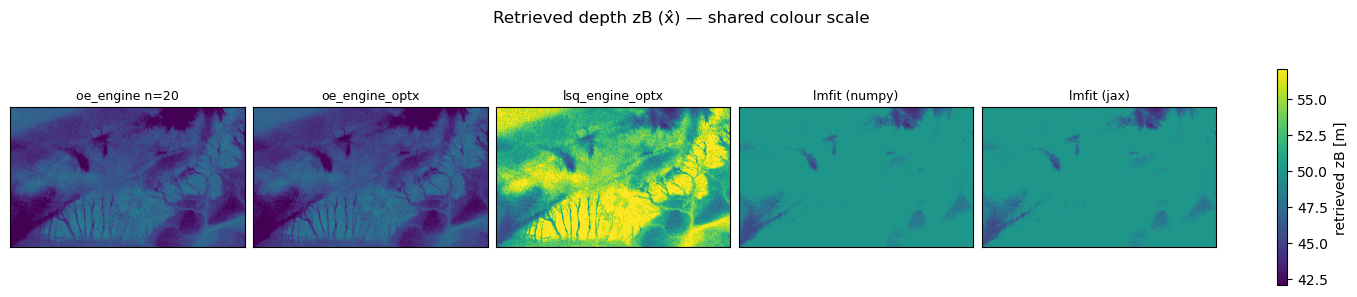

In [14]:
# Maps show the retrieved depth zB (x_hat). chi2_spectral still needs ŷ, so it is rebuilt
# from each engine's zB via the SHARED JAX forward, making chi2_spectral = mean((Rrs-ŷ)^2)
# comparable across engines (identical forward; differs only by the retrieved zB).
zb_idx     = param_names.index('zB')
P          = len(param_names)
x_prior_np = np.array(x_prior, dtype=np.float64)
_yhat_fn   = jax.jit(jax.vmap(f_vec))   # compiled once, reused for all engines

def _zb_map(res):
    zb = np.asarray(res['x_hat'])
    return zb[..., 0] if zb.ndim == 3 else zb        # (n_rows, n_cols) physical zB [m]

def _yhat_from_zb(zb):
    full = np.tile(x_prior_np, (*zb.shape, 1))
    full[..., zb_idx] = zb
    yh   = np.array(_yhat_fn(jnp.asarray(full.reshape(-1, P), dtype=jnp.float64)))
    return yh.reshape(*zb.shape, n_obs)

engines = [
    (f'oe_engine n={N_ITER}', res_oe,        t_oe,        chi2_oe),
    ('oe_engine_optx',        res_oe_optx,   t_oe_optx,   chi2_oe_optx),
    ('lsq_engine_optx',       res_lsq,       t_lsq,       chi2_lsq),
    ('lmfit (numpy)',         res_lmfit_np,  t_lmfit_np,  chi2_lmfit_np),
    ('lmfit (jax)',           res_lmfit_jax, t_lmfit_jax, chi2_lmfit_jax),
]
zbs = {name: _zb_map(res) for name, res, _, _ in engines}

# --- metric table: retrieved zB + engine-reported chi2 vs uniform chi2_spectral ------
print(f'{"engine":<22} {"run_s":>7} {"zB_med":>7} {"chi2(rep)":>10} {"chi2_spec":>11} {"chi2_norm":>10}')
print('-' * 72)
for name, res, t, chi2_rep in engines:
    zb       = zbs[name]
    resid    = Rrs_image - _yhat_from_zb(zb)             # (n_rows, n_cols, n_obs)
    chi2_sp  = float(np.nanmedian(np.mean(resid**2, axis=-1)))
    chi2_nrm = chi2_sp / NOISE**2                        # uniform noise-normalised
    print(f'{name:<22} {t:>7.1f} {np.nanmedian(zb):>7.2f} {chi2_rep:>10.4g} {chi2_sp:>11.2e} {chi2_nrm:>10.3f}')
print('\nchi2(rep) = engine-reported (lmfit = raw SSR; oe/lsq = noise-norm) — NOT comparable.')
print('chi2_spec = mean((Rrs-ŷ)^2);  chi2_norm = chi2_spec / NOISE^2 — both uniform & comparable.')
print('Sanity: chi2_norm ≈ chi2(rep) for oe/lsq;  chi2(rep)_lmfit ≈ n_obs · chi2_spec.')

# --- retrieved zB (x_hat) maps side by side, shared colour scale ---------------------
zb_all     = np.concatenate([zb[np.isfinite(zb)].ravel() for zb in zbs.values()])
vmin, vmax = np.nanpercentile(zb_all, [2, 98])

fig, axes = plt.subplots(1, len(engines), figsize=(2.7 * len(engines), 3.2),
                         constrained_layout=True)
for ax, (name, *_) in zip(axes, engines):
    im = ax.imshow(zbs[name], vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.75, label='retrieved zB [m]')
fig.suptitle('Retrieved depth zB (x̂) — shared colour scale', fontsize=12)
plt.show()

## 5  n_steps distribution (dynamic engines)

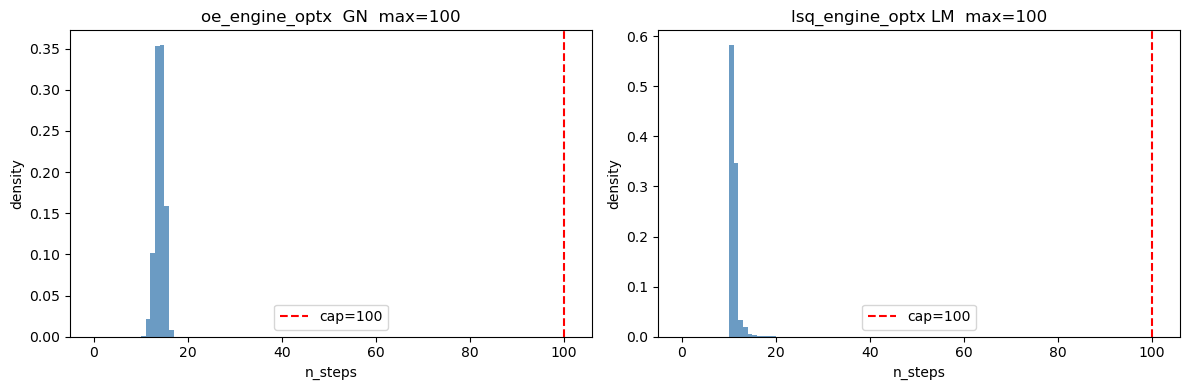

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ns_arr, label in [
    (axes[0], ns_optx_v,  f'oe_engine_optx  GN  max={MAX_STEPS}'),
    (axes[1], ns_lsq_v,   f'lsq_engine_optx LM  max={MAX_STEPS}'),
]:
    ax.hist(ns_arr, bins=range(0, MAX_STEPS + 2), density=True, color='steelblue', alpha=0.8)
    ax.axvline(MAX_STEPS, color='r', ls='--', lw=1.5, label=f'cap={MAX_STEPS}')
    ax.set_xlabel('n_steps')
    ax.set_ylabel('density')
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.show()

## 6  tile_size sweep — oe_engine_optx

Smaller tiles reduce the one-hard-pixel-holds-the-batch effect at the cost of
more per-tile dispatch overhead and more JIT recompilations (one per distinct size).

In [16]:
TILE_SIZES = [64, 256, 1024, 4096, 16384, 65536]

# Warm up JIT for each tile size before timing
for ts in TILE_SIZES:
    dummy_ts = np.tile(_prior_rrs, (ts, 1))
    oe_engine_optx.invert_image_optx(
        dummy_ts, setup, NOISE, solver='GaussNewton', max_steps=MAX_STEPS
    )
    print(f'tile_size={ts:>6}  JIT warmed', flush=True)

tile_size=    64  JIT warmed
tile_size=   256  JIT warmed
tile_size=  1024  JIT warmed
tile_size=  4096  JIT warmed
tile_size= 16384  JIT warmed
tile_size= 65536  JIT warmed


In [17]:
sweep = []
for ts in TILE_SIZES:
    t0 = time.perf_counter()
    r = dask_engine.invert_image(
        Rrs_image, setup, NOISE,
        invert_fn=oe_engine_optx.invert_image_optx,
        tile_size=ts,
        solver='GaussNewton',
        max_steps=MAX_STEPS,
    )
    t = time.perf_counter() - t0
    ns_s  = r['n_steps']
    ns_s  = ns_s[ns_s >= 0]
    n_tiles = int(np.ceil(n_rows * n_cols / ts))
    med   = float(np.median(ns_s))
    sat   = float(100 * (ns_s == MAX_STEPS).mean())
    sweep.append(dict(tile_size=ts, wall_s=t, ms_px=1000*t/n_water,
                      n_tiles=n_tiles, n_steps_med=med, pct_at_max=sat))
    print(f'ts={ts:>6}  {t:6.1f}s  {1000*t/n_water:.2f}ms/px  '
          f'tiles={n_tiles:4d}  med={med:.0f}  sat={sat:.1f}%')

ts=    64    13.9s  0.12ms/px  tiles=1874  med=14  sat=0.0%
ts=   256     7.4s  0.06ms/px  tiles= 469  med=14  sat=0.0%
ts=  1024     5.6s  0.05ms/px  tiles= 118  med=14  sat=0.0%
ts=  4096     9.8s  0.08ms/px  tiles=  30  med=14  sat=0.0%
ts= 16384     8.7s  0.07ms/px  tiles=   8  med=14  sat=0.0%
ts= 65536     9.1s  0.08ms/px  tiles=   2  med=14  sat=0.0%


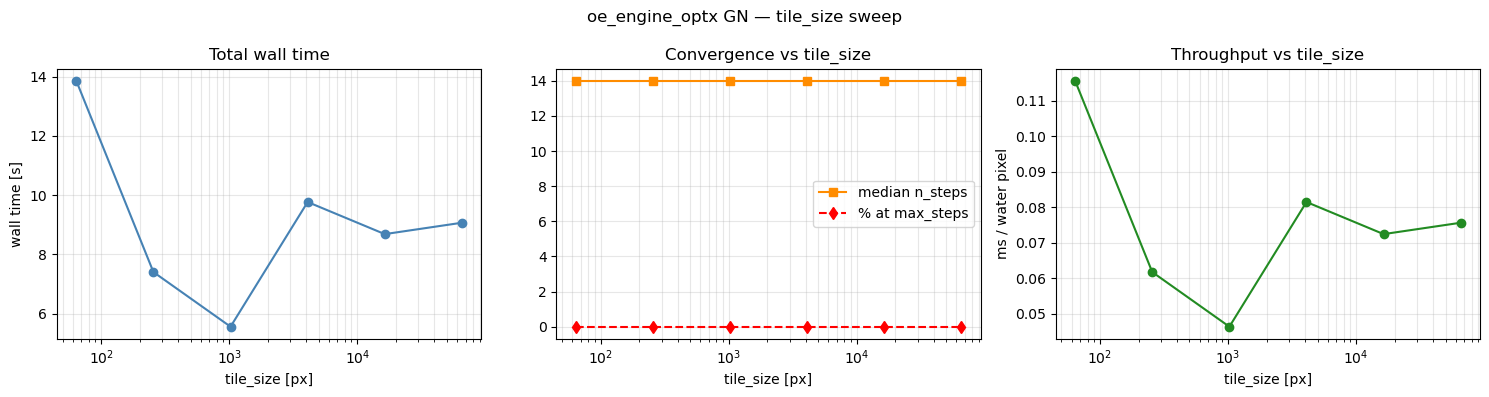

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ts_list    = [s['tile_size']   for s in sweep]
t_list     = [s['wall_s']      for s in sweep]
ms_list    = [s['ms_px']       for s in sweep]
sat_list   = [s['pct_at_max']  for s in sweep]
med_list   = [s['n_steps_med'] for s in sweep]

axes[0].semilogx(ts_list, t_list, 'o-', color='steelblue')
axes[0].set_xlabel('tile_size [px]')
axes[0].set_ylabel('wall time [s]')
axes[0].set_title('Total wall time')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(ts_list, med_list, 's-', color='darkorange', label='median n_steps')
axes[1].semilogx(ts_list, sat_list, 'd--', color='red', label='% at max_steps')
axes[1].set_xlabel('tile_size [px]')
axes[1].set_title('Convergence vs tile_size')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

axes[2].semilogx(ts_list, ms_list, 'o-', color='forestgreen')
axes[2].set_xlabel('tile_size [px]')
axes[2].set_ylabel('ms / water pixel')
axes[2].set_title('Throughput vs tile_size')
axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle('oe_engine_optx GN — tile_size sweep', fontsize=12)
plt.tight_layout()
plt.show()